# 01 — Basic EDA

**Amaç:** Şema, kolon rolleri ve target dengesini doğrulamak. Bu notebook model eğitmez.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from kaggle_s6_e7.config import (FIGURES_DIR, TABLES_DIR, TARGET_COL, ID_COL,
    PLOT_SAMPLE_SIZE, RANDOM_STATE, ensure_report_dirs)
from kaggle_s6_e7.data import load_competition_data, infer_feature_columns, validate_schema
ensure_report_dirs()
train, test = load_competition_data()
validate_schema(train, test)
cat_cols, num_cols = infer_feature_columns(train)
plot_df = train.sample(min(PLOT_SAMPLE_SIZE, len(train)), random_state=RANDOM_STATE)
sns.set_theme(style="whitegrid")

## Dataset shape ve örnekler

In [2]:
print("train:", train.shape, "test:", test.shape)
display(train.head())
display(test.head())
train.info()

train: (690088, 15) test: (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

## Kolon rolleri ve özet istatistikler

In [3]:
print("Categorical:", cat_cols)
print("Numeric:", num_cols)
display(train[num_cols].describe(percentiles=[.01,.05,.5,.95,.99]).T)
for col in cat_cols:
    print(f"\n{col}")
    display(train[col].value_counts(dropna=False).to_frame("count"))

Categorical: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
Numeric: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']


,count,mean,std,min,1%,5%,50%,95%,99%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,4.19,4.95,6.99,9.05,9.92,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,56.30,61.80,75.10,88.60,93.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,17.15,18.87,22.99,27.08,28.84,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,1404.00,1626.00,2241.00,2781.00,2979.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,1211.00,1769.00,8856.00,14253.00,14762.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,0.00,14.40,39.40,61.40,67.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,0.86,1.42,2.17,3.12,3.44,4.72



diet_type


,count
diet_type,
veg,231432
balanced,226888
non-veg,224867
NaN,6901



stress_level


...

,count
physical_activity_level,
moderate,221041
sedentary,219784
active,212642
NaN,36621



smoking_alcohol


,count
smoking_alcohol,
yes,223730
no,219791
occasional,217985
NaN,28582



gender


,count
gender,
male,237756
female,224016
other,206943
NaN,21373


## Target dağılımı

,count,rate
health_condition,,
at-risk,592561,0.858675
unhealthy,57724,0.083647
fit,39803,0.057678


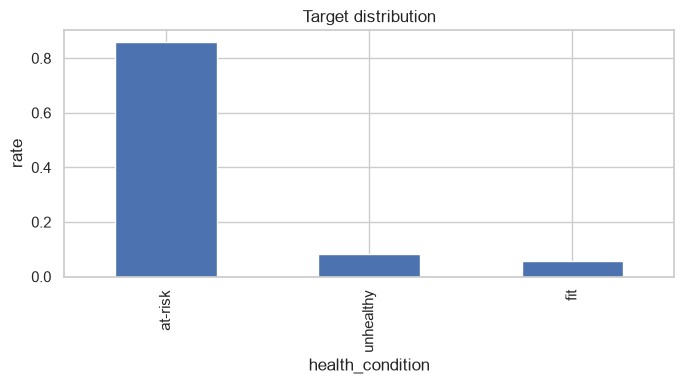

In [4]:
from kaggle_s6_e7.eda import target_summary
target_table = target_summary(train, TARGET_COL)
display(target_table)
target_table.to_csv(TABLES_DIR / "01_target_distribution.csv")
ax = target_table["rate"].plot.bar(figsize=(7,4), title="Target distribution")
ax.set_ylabel("rate"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_target_distribution.png", dpi=150); plt.show()

## Karar notu

Balanced accuracy ana metric olduğundan gelecekte yalnız accuracy değil, **sınıf bazlı recall** da izlenmelidir. Doğrulanan yorumları `reports/eda_findings.md` içine aktar.